## 1. Setup and Imports

In [15]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Project imports
from config.config import Config
from src.data_loader import StockDataLoader
from src.data_preprocessor import StockDataPreprocessor
from src.model import LSTMStockModel
from src.trainer import ModelTrainer
from utils.helpers import split_train_val_test, save_scaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(" Imports successful")

TensorFlow version: 2.19.0
GPU available: []
 Imports successful


## 2. Configuration

In [16]:
# Initialize configuration
config = Config()

# Display configuration
print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"\nData Config:")
print(f"  - Raw data path: {config.data.raw_data_path}")
print(f"  - Target column: {config.data.target_column}")
print(f"  - Feature columns: {config.data.feature_columns}")

print(f"\nPreprocessing Config:")
print(f"  - Sequence length: {config.preprocessing.sequence_length}")
print(f"  - Train ratio: {config.preprocessing.train_ratio}")
print(f"  - Validation ratio: {config.preprocessing.validation_ratio}")
print(f"  - Test ratio: {config.preprocessing.test_ratio}")

print(f"\nModel Config:")
print(f"  - Model type: {config.model.model_type}")
print(f"  - LSTM units: {config.model.lstm_units}")
print(f"  - Dropout rate: {config.model.dropout_rate}")
print(f"  - Learning rate: {config.model.learning_rate}")

print(f"\nTraining Config:")
print(f"  - Epochs: {config.training.epochs}")
print(f"  - Batch size: {config.training.batch_size}")
print(f"  - Early stopping patience: {config.training.early_stopping_patience}")

CONFIGURATION

Data Config:
  - Raw data path: data/processed/lstm_ready_data.csv
  - Target column: Close
  - Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume']

Preprocessing Config:
  - Sequence length: 12
  - Train ratio: 0.8
  - Validation ratio: 0.1
  - Test ratio: 0.1

Model Config:
  - Model type: stacked_lstm
  - LSTM units: [50, 50]
  - Dropout rate: 0.2
  - Learning rate: 0.001

Training Config:
  - Epochs: 100
  - Batch size: 32
  - Early stopping patience: 15


## 3. Load and Prepare Data

In [17]:
# Load data
data_path = project_root / config.data.raw_data_path
print(f"Loading data from: {data_path}")

data_loader = StockDataLoader(str(data_path))
df = data_loader.load_csv(date_column=config.data.date_column)

print(f"\n✓ Loaded {len(df):,} records")
print(f"✓ Columns: {list(df.columns)}")
print(f"✓ Date range: {df[config.data.date_column].min()} to {df[config.data.date_column].max()}")

df.head()

INFO:src.data_loader:Loaded 245 records from c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv


Loading data from: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv

✓ Loaded 245 records
✓ Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
✓ Date range: 2000-01-01 00:00:00 to 2020-06-01 00:00:00


,Date,Open,High,Low,Close,Volume
0,2000-01-01,102.860335,43.043575,40.854469,102.860335,18412.0
1,2000-02-01,82.811518,40.917801,38.652880,82.827225,15820.0
2,2000-03-01,71.360406,34.579695,31.312690,71.375635,14061.0
3,2000-04-01,38.967033,33.376923,31.453846,39.368132,7165.0
4,2000-05-01,76.277778,36.832500,33.632778,76.477778,13766.0


In [18]:
# Preprocess data
preprocessor = StockDataPreprocessor(
    feature_columns=config.data.feature_columns,
    target_column=config.data.target_column
)

# Handle missing values
df = preprocessor.handle_missing_values(df, method=config.preprocessing.missing_value_method)

print(f" Preprocessed data shape: {df.shape}")
print(f" Missing values: {df.isnull().sum().sum()}")

 Preprocessed data shape: (245, 6)
 Missing values: 0


## 4. Feature Scaling

In [19]:
# Extract features and target
features = df[config.data.feature_columns].values
target = df[config.data.target_column].values.reshape(-1, 1)

print(f"Features shape: {features.shape}")
print(f"Target shape: {target.shape}")

# Scale features
feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = feature_scaler.fit_transform(features)

# Scale target
target_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_target = target_scaler.fit_transform(target)

print(f"\n Scaled features shape: {scaled_features.shape}")
print(f" Scaled target shape: {scaled_target.shape}")

# Save scalers
scaler_dir = project_root / 'models' / 'scalers'
scaler_dir.mkdir(parents=True, exist_ok=True)

import joblib
joblib.dump(feature_scaler, scaler_dir / 'feature_scaler.pkl')
joblib.dump(target_scaler, scaler_dir / 'target_scaler.pkl')
print(f"\n✓ Scalers saved to {scaler_dir}")

Features shape: (245, 5)
Target shape: (245, 1)

 Scaled features shape: (245, 5)
 Scaled target shape: (245, 1)

✓ Scalers saved to c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\scalers


## 5. Create Sequences

In [20]:
def create_sequences(features, target, sequence_length):
    """
    Create sequences for LSTM training.
    
    Args:
        features: Scaled feature array
        target: Scaled target array
        sequence_length: Number of time steps to look back
    
    Returns:
        X: Sequences of features (samples, sequence_length, n_features)
        y: Target values (samples, 1)
    """
    X, y = [], []
    
    for i in range(sequence_length, len(features)):
        X.append(features[i-sequence_length:i])
        y.append(target[i])
    
    return np.array(X), np.array(y)

# Create sequences
sequence_length = config.preprocessing.sequence_length
print(f"Creating sequences with length: {sequence_length}")

X, y = create_sequences(scaled_features, scaled_target, sequence_length)

print(f"\n Sequence shape: {X.shape}")
print(f" Target shape: {y.shape}")
print(f" Total samples: {len(X):,}")

Creating sequences with length: 12

 Sequence shape: (233, 12, 5)
 Target shape: (233, 1)
 Total samples: 233


## 6. Split Data

In [21]:
# Split into train, validation, and test sets
train_size = int(len(X) * config.preprocessing.train_ratio)
val_size = int(len(X) * config.preprocessing.validation_ratio)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)
print(f"\nTraining set:")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"  - Samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")

print(f"\nValidation set:")
print(f"  - X_val shape: {X_val.shape}")
print(f"  - y_val shape: {y_val.shape}")
print(f"  - Samples: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")

print(f"\nTest set:")
print(f"  - X_test shape: {X_test.shape}")
print(f"  - y_test shape: {y_test.shape}")
print(f"  - Samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

DATA SPLIT

Training set:
  - X_train shape: (186, 12, 5)
  - y_train shape: (186, 1)
  - Samples: 186 (79.8%)

Validation set:
  - X_val shape: (23, 12, 5)
  - y_val shape: (23, 1)
  - Samples: 23 (9.9%)

Test set:
  - X_test shape: (24, 12, 5)
  - y_test shape: (24, 1)
  - Samples: 24 (10.3%)


## 7. Build Model

In [22]:
# Input shape
input_shape = (X_train.shape[1], X_train.shape[2])
print(f"Input shape: {input_shape}")

# Build model
lstm_model_builder = LSTMStockModel(input_shape=input_shape)

# Choose model architecture based on config
if config.model.model_type == 'simple_lstm':
    model = lstm_model_builder.build_simple_lstm(
        units=config.model.lstm_units[0],
        dropout=config.model.dropout_rate
    )
elif config.model.model_type == 'stacked_lstm':
    model = lstm_model_builder.build_stacked_lstm(
        units=config.model.lstm_units,
        dropout=config.model.dropout_rate
    )
elif config.model.model_type == 'bidirectional_lstm':
    model = lstm_model_builder.build_bidirectional_lstm(
        units=config.model.lstm_units,
        dropout=config.model.dropout_rate
    )
else:
    print(f"Unknown model type: {config.model.model_type}")
    print("Using stacked LSTM as default")
    model = lstm_model_builder.build_stacked_lstm(
        units=config.model.lstm_units,
        dropout=config.model.dropout_rate
    )

# Compile model
optimizer = keras.optimizers.Adam(learning_rate=config.model.learning_rate)
model.compile(
    optimizer=optimizer,
    loss='mean_squared_error',
    metrics=['mean_absolute_error', 'mean_absolute_percentage_error']
)

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
model.summary()

Input shape: (12, 5)


INFO:src.model:Built stacked LSTM model with layers: [50, 50]



MODEL ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Setup Callbacks

In [23]:
# Create directories
model_dir = project_root / 'models' / 'saved_models'
checkpoint_dir = project_root / 'models' / 'checkpoints'
log_dir = project_root / 'logs' / f'training_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

model_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

# Define callbacks
callback_list = [
    # Early stopping
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config.training.early_stopping_patience,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Model checkpoint
    callbacks.ModelCheckpoint(
        filepath=str(checkpoint_dir / 'model_epoch_{epoch:02d}_valloss_{val_loss:.4f}.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    
    # Reduce learning rate
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=config.training.reduce_lr_patience,
        min_lr=1e-7,
        verbose=1
    ),
    
    # TensorBoard
    callbacks.TensorBoard(
        log_dir=str(log_dir),
        histogram_freq=1
    ),
    
    # CSV Logger
    callbacks.CSVLogger(
        filename=str(log_dir / 'training_log.csv'),
        separator=',',
        append=False
    )
]

print("✓ Callbacks configured")
print(f"  - Model checkpoints: {checkpoint_dir}")
print(f"  - Training logs: {log_dir}")

✓ Callbacks configured
  - Model checkpoints: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\checkpoints
  - Training logs: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_113118


## 9. Train Model

In [24]:
# Train the model
print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)
print(f"Epochs: {config.training.epochs}")
print(f"Batch size: {config.training.batch_size}")
print(f"\nTraining started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=config.training.epochs,
    batch_size=config.training.batch_size,
    callbacks=callback_list,
    verbose=1,
    shuffle=config.training.shuffle
)

print(f"\n Training completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


STARTING TRAINING
Epochs: 100
Batch size: 32

Training started at: 2026-03-01 11:31:18

Epoch 1/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0021 - mean_absolute_error: 0.0357 - mean_absolute_percentage_error: 41666.9219
Epoch 1: val_loss improved from None to 0.02387, saving model to c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\checkpoints\model_epoch_01_valloss_0.0239.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0276 - mean_absolute_error: 0.1124 - mean_absolute_percentage_error: 7221.4019 - val_loss: 0.0239 - val_mean_absolute_error: 0.1491 - val_mean_absolute_percentage_error: 167.0648 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0116 - mean_absolute_error: 0.0791 - mean_absolute_percentage_error: 973984.9375 
Epoch 2: val_loss improved from 0.02387 to 0.01786, saving model to c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\checkpoin

## 10. Save Model

In [25]:
# Save the final model
model_save_path = model_dir / f'lstm_model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.keras'
model.save(model_save_path)
print(f" Model saved to: {model_save_path}")

# Save training history
history_df = pd.DataFrame(history.history)
history_csv_path = log_dir / 'training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f" Training history saved to: {history_csv_path}")

 Model saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\saved_models\lstm_model_20260301_113127.keras
 Training history saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_113118\training_history.csv


## 11. Visualize Training History

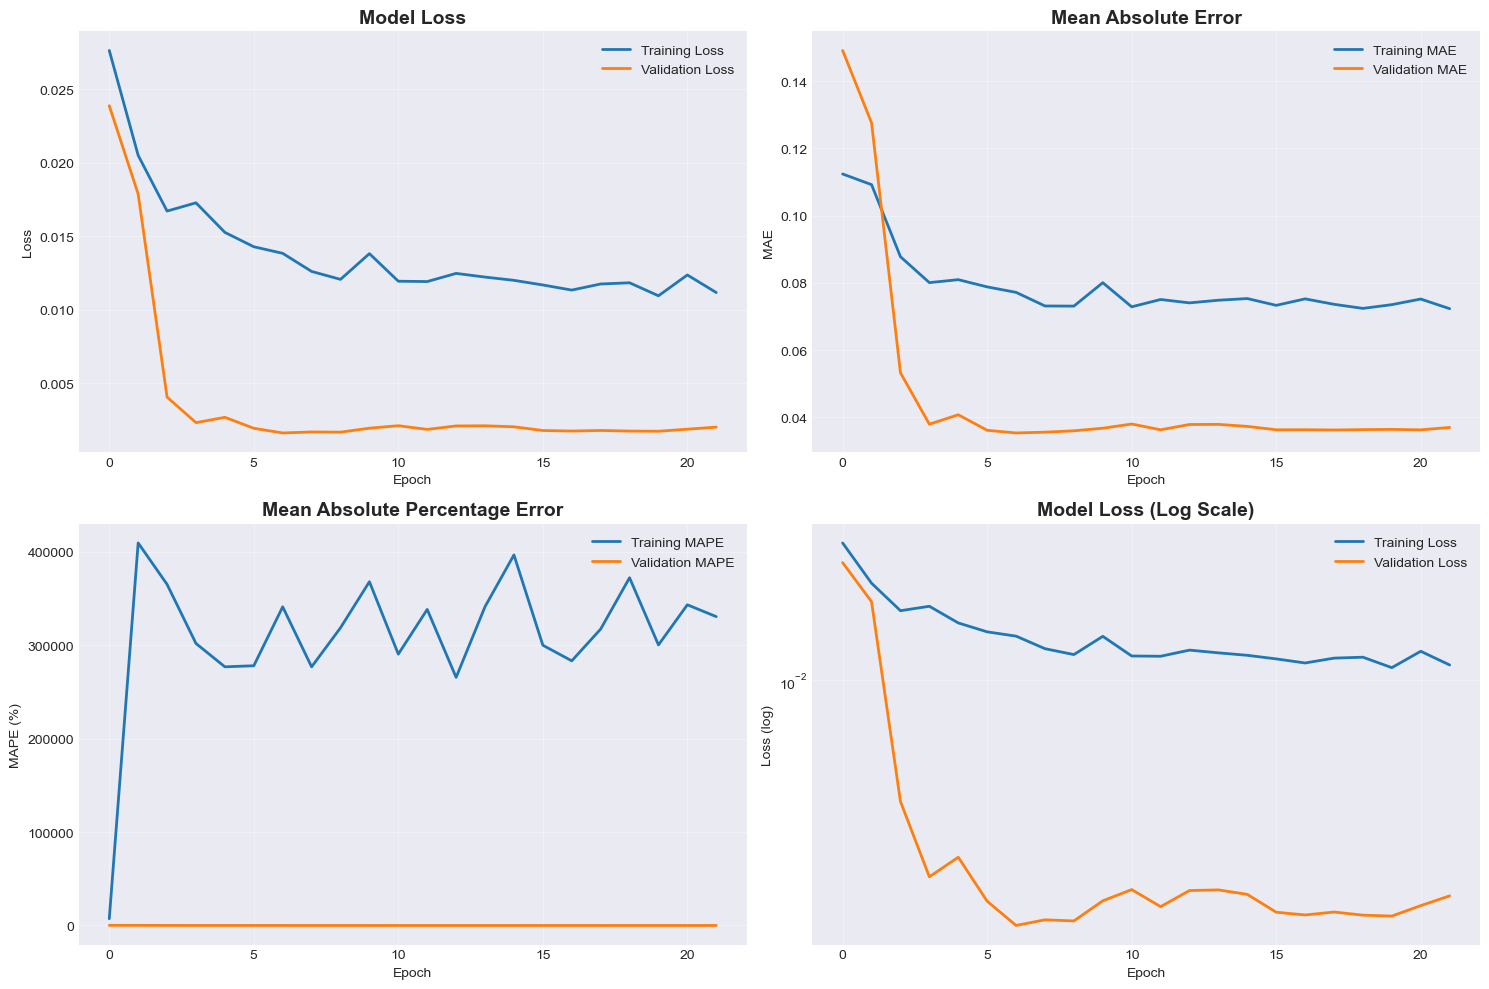

 Training plots saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_113118\training_history.png


In [26]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE
axes[0, 1].plot(history.history['mean_absolute_error'], label='Training MAE', linewidth=2)
axes[0, 1].plot(history.history['val_mean_absolute_error'], label='Validation MAE', linewidth=2)
axes[0, 1].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# MAPE
axes[1, 0].plot(history.history['mean_absolute_percentage_error'], label='Training MAPE', linewidth=2)
axes[1, 0].plot(history.history['val_mean_absolute_percentage_error'], label='Validation MAPE', linewidth=2)
axes[1, 0].set_title('Mean Absolute Percentage Error', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MAPE (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss (log scale)
axes[1, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1, 1].set_title('Model Loss (Log Scale)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss (log)')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(log_dir / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Training plots saved to: {log_dir / 'training_history.png'}")

## 12. Training Summary

In [27]:
# Display training summary
print("=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)

final_epoch = len(history.history['loss'])
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_mae = history.history['mean_absolute_error'][-1]
final_val_mae = history.history['val_mean_absolute_error'][-1]
final_train_mape = history.history['mean_absolute_percentage_error'][-1]
final_val_mape = history.history['val_mean_absolute_percentage_error'][-1]

best_val_loss = min(history.history['val_loss'])
best_epoch = history.history['val_loss'].index(best_val_loss) + 1

print(f"\ Training Configuration:")
print(f"  - Model Type: {config.model.model_type}")
print(f"  - LSTM Units: {config.model.lstm_units}")
print(f"  - Sequence Length: {config.preprocessing.sequence_length}")
print(f"  - Total Epochs Trained: {final_epoch}")
print(f"  - Batch Size: {config.training.batch_size}")

print(f"\n Final Metrics (Epoch {final_epoch}):")
print(f"  - Training Loss: {final_train_loss:.6f}")
print(f"  - Validation Loss: {final_val_loss:.6f}")
print(f"  - Training MAE: {final_train_mae:.6f}")
print(f"  - Validation MAE: {final_val_mae:.6f}")
print(f"  - Training MAPE: {final_train_mape:.2f}%")
print(f"  - Validation MAPE: {final_val_mape:.2f}%")

print(f"\n Best Performance:")
print(f"  - Best Validation Loss: {best_val_loss:.6f}")
print(f"  - Best Epoch: {best_epoch}")

print(f"\n Saved Artifacts:")
print(f"  - Model: {model_save_path}")
print(f"  - Training History: {history_csv_path}")
print(f"  - Plots: {log_dir}")
print(f"  - Scalers: {scaler_dir}")

print("\n✓ Model training completed successfully!")

TRAINING SUMMARY
\ Training Configuration:
  - Model Type: stacked_lstm
  - LSTM Units: [50, 50]
  - Sequence Length: 12
  - Total Epochs Trained: 22
  - Batch Size: 32

 Final Metrics (Epoch 22):
  - Training Loss: 0.011163
  - Validation Loss: 0.002010
  - Training MAE: 0.072290
  - Validation MAE: 0.036967
  - Training MAPE: 330642.03%
  - Validation MAPE: 33.61%

 Best Performance:
  - Best Validation Loss: 0.001613
  - Best Epoch: 7

 Saved Artifacts:
  - Model: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\saved_models\lstm_model_20260301_113127.keras
  - Training History: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_113118\training_history.csv
  - Plots: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_113118
  - Scalers: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\

## 13. Quick Prediction Test

Testing model on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step

 Test Set Performance:
  - RMSE: 144.2107
  - MAE: 102.9783
  - MAPE: 27.53%
  - R² Score: 0.0965


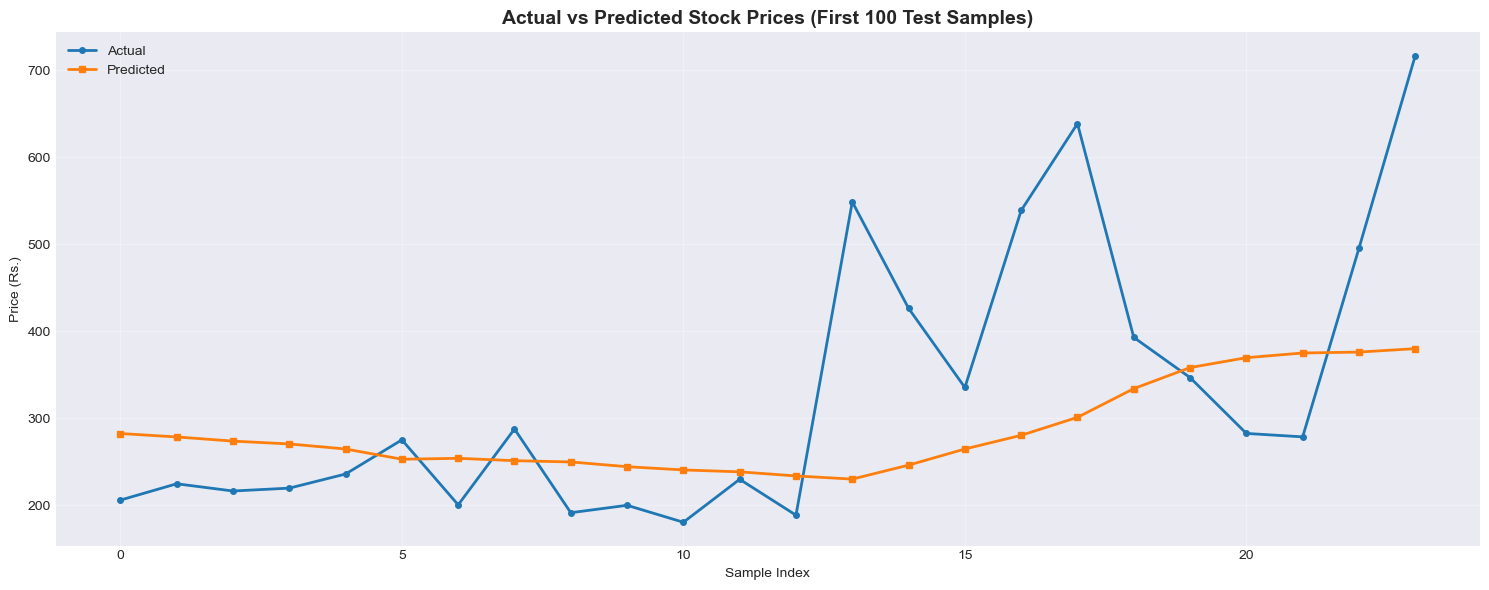

In [28]:
# Make predictions on test set
print("Testing model on test set...")
y_pred_test = model.predict(X_test)

# Inverse transform predictions
y_test_actual = target_scaler.inverse_transform(y_test)
y_pred_actual = target_scaler.inverse_transform(y_pred_test)

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"\n Test Set Performance:")
print(f"  - RMSE: {rmse:.4f}")
print(f"  - MAE: {mae:.4f}")
print(f"  - MAPE: {mape:.2f}%")
print(f"  - R² Score: {r2:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[:100], label='Actual', marker='o', markersize=4, linewidth=2)
plt.plot(y_pred_actual[:100], label='Predicted', marker='s', markersize=4, linewidth=2)
plt.title('Actual vs Predicted Stock Prices (First 100 Test Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Price (Rs.)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(log_dir / 'quick_prediction_test.png', dpi=300, bbox_inches='tight')
plt.show()

## Next Steps

Model training is complete! Proceed to:
1. **Notebook 03**: Model Evaluation - Comprehensive model performance analysis
2. **Notebook 04**: Model Validation - Validate predictions on different time periods
3. **Notebook 05**: Ensemble Analysis - Train and compare multiple models